<a href="https://colab.research.google.com/github/RodrigoCasanova/Backend/blob/main/Paillan_lee_esto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación de Datos y Modelos de Regresión

**Autores:**
- Juan Mora
- Benjamin Camus
- Jose Paillan

**Correos:** jua.morar@duocuc.cl

**Fecha de Creación:** Mayo de 2026  
**Versión:** 1.0

---

## Descripción

Este notebook corresponde a la Fase 2 del proyecto semestral de Minería de Datos (BIY7121). Se aplican las fases 3 y 4 de la metodología CRISP-DM: preparación de datos y modelamiento, sobre un conjunto de datos climáticos históricos de Chile del año 2025.

El caso de estudio es una empresa agrícola cuya producción depende directamente de las condiciones climáticas. Predecir la temperatura permite anticipar heladas, planificar riegos y optimizar la cosecha. La variable objetivo es `temperature_2m`.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)
- seaborn (0.13.1)
- scikit-learn (1.6.0)

## Carga de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin

RANDOM_STATE = 29

In [ ]:
url = "https://raw.githubusercontent.com/juanpablomora36/mineria-datos-clima/main/data_clima_2025_final.csv"
data = pd.read_csv(url)
data['date'] = pd.to_datetime(data['date'], utc=True)
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


In [ ]:
data.shape

(33024, 15)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   date                  33024 non-null  datetime64[ns, UTC]
 1   temperature_2m        33024 non-null  float64            
 2   relative_humidity_2m  33024 non-null  float64            
 3   apparent_temperature  33024 non-null  float64            
 4   precipitation         33024 non-null  float64            
 5   cloud_cover           33024 non-null  float64            
 6   wind_speed_10m        33024 non-null  float64            
 7   wind_direction_10m    33024 non-null  float64            
 8   rain                  33024 non-null  float64            
 9   is_day                33024 non-null  float64            
 10  sunshine_duration     33024 non-null  float64            
 11  Localidad             33024 non-null  object             
 12  lati

**Descripción del dataset:** El conjunto de datos cuenta con 33.024 registros y 15 columnas. La columna `date` fue convertida a formato datetime para poder extraer variables temporales. Todas las columnas numéricas son de tipo `float64` o `int64`. La columna `Localidad` es de tipo texto y será codificada en la etapa de preparación de datos mediante `OneHotEncoder`.

---
# Fase 2 – Entendimiento de los Datos

## 1. Identificación de Valores Duplicados

Se revisa la existencia de registros duplicados en el conjunto de datos, es decir, filas que presenten exactamente los mismos valores en todas sus columnas.

In [ ]:
duplicados = data[data.duplicated()]
print(f'Cantidad de registros duplicados: {len(duplicados)}')
duplicados

Cantidad de registros duplicados: 0


,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour


**Hallazgo:** No se identificaron registros duplicados en el conjunto de datos. Cada observación corresponde a una medición horaria única por localidad, lo cual es consistente con la naturaleza de los datos provenientes de estaciones meteorológicas. Al no existir duplicados, no se requiere aplicar ningún tratamiento en esta dimensión. De existir duplicados en el futuro, la acción correcta sería eliminarlos mediante `drop_duplicates()` para evitar que el modelo aprenda patrones artificialmente repetidos.

## 2. Identificación de Valores Nulos

Se analiza la presencia de valores faltantes en cada variable del conjunto de datos, incluyendo el porcentaje que representan sobre el total de registros.

In [ ]:
nulos = data.isna().sum().rename('Cantidad de nulos')
nulos_pct = (nulos / len(data) * 100).rename('% de nulos')
pd.concat([nulos, nulos_pct], axis=1)

,Cantidad de nulos,% de nulos
date,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
apparent_temperature,0,0.0
precipitation,0,0.0
cloud_cover,0,0.0
wind_speed_10m,0,0.0
wind_direction_10m,0,0.0
rain,0,0.0
is_day,0,0.0


**Hallazgo:** No se identificaron valores nulos en ninguna de las variables del conjunto de datos. El dataset se encuentra completamente íntegro con 33.024 registros válidos en todas sus columnas.

Al no existir valores faltantes, no se requiere aplicar técnicas de imputación en esta etapa. No obstante, el pipeline ha sido configurado con un `SimpleImputer` como buena práctica, considerando que datos futuros podrían presentar esta situación.

## 3. Identificación de Valores Atípicos

Se identifican valores extremos en las variables numéricas mediante el método del rango intercuartílico (IQR). Este método define como atípicos aquellos valores que se encuentran fuera del intervalo `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.

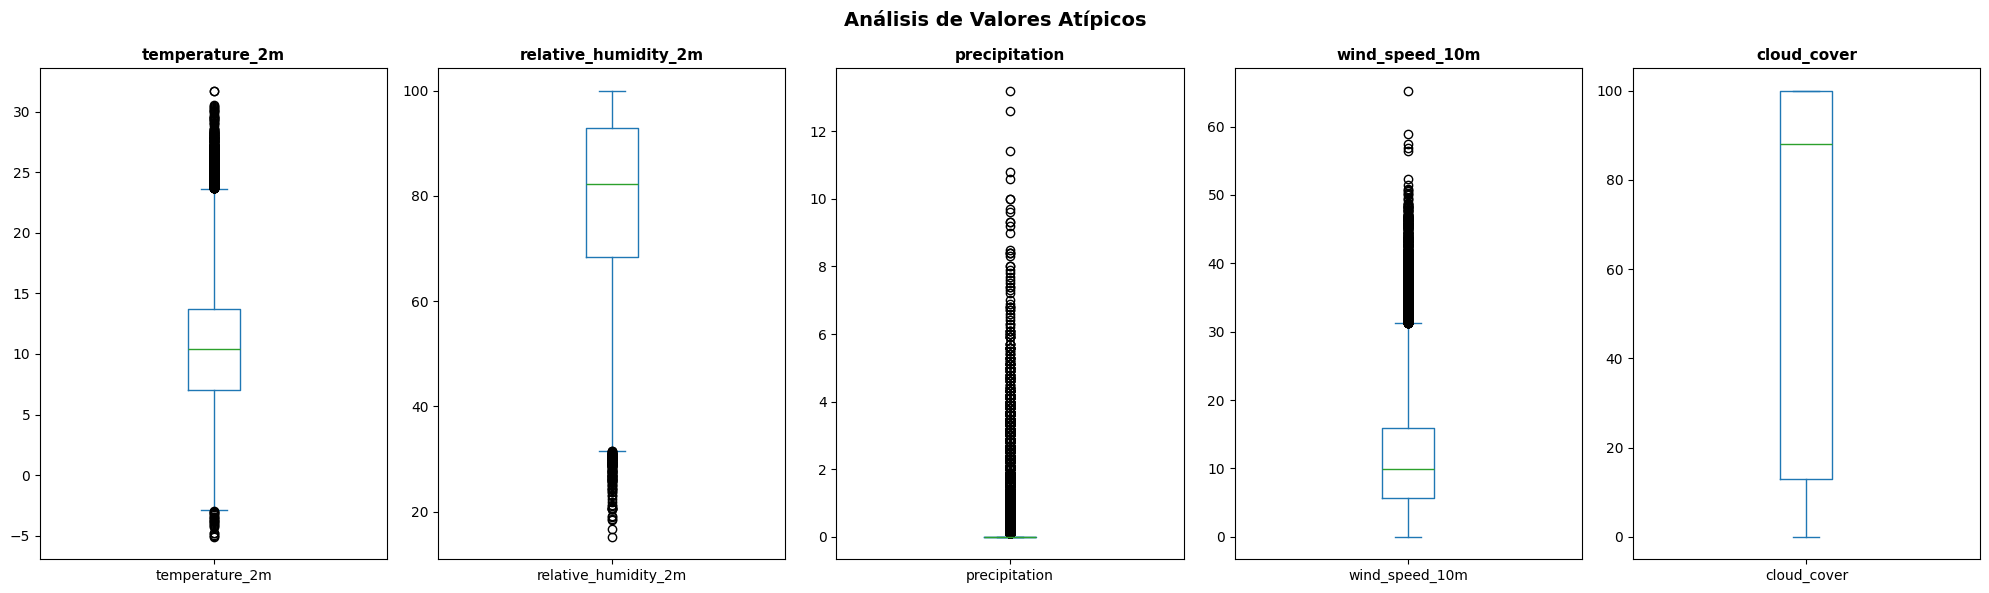

In [ ]:
variables_atipicos = ['temperature_2m', 'relative_humidity_2m',
                      'precipitation', 'wind_speed_10m', 'cloud_cover']

fig, axes = plt.subplots(1, len(variables_atipicos), figsize=(20, 6))
for i, col in enumerate(variables_atipicos):
    data[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')

plt.suptitle('Análisis de Valores Atípicos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
for col in variables_atipicos:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = len(data[(data[col] < lower) | (data[col] > upper)])
    print(f'{col:<25} | Límite inf: {lower:>7.2f} | Límite sup: {upper:>7.2f} | Atípicos: {n}')

temperature_2m            | Límite inf:   -2.92 | Límite sup:   23.67 | Atípicos: 476
relative_humidity_2m      | Límite inf:   31.54 | Límite sup:  129.70 | Atípicos: 130
precipitation             | Límite inf:    0.00 | Límite sup:    0.00 | Atípicos: 6152
wind_speed_10m            | Límite inf:   -9.70 | Límite sup:   31.23 | Atípicos: 1241
cloud_cover               | Límite inf: -117.50 | Límite sup:  230.50 | Atípicos: 0


**Hallazgo:** Se identificaron valores atípicos en las siguientes variables:

- `temperature_2m`: 476 registros fuera del intervalo [-2.92°C, 23.67°C], correspondientes a heladas y olas de calor. Son eventos climáticos reales, no errores.
- `precipitation`: 6.152 registros atípicos. Esto se debe a que la mayoría de las horas no registra lluvia (valor 0), por lo que cualquier precipitación queda fuera del rango IQR. Estos valores son válidos y esperables.
- `wind_speed_10m`: 1.241 registros correspondientes a ráfagas de viento intensas, coherentes con el clima del sur de Chile.
- `relative_humidity_2m`: 130 registros con humedad muy baja, posiblemente asociados a condiciones de sequía o días de alto calor.
- `cloud_cover`: No presenta valores atípicos, su distribución abarca naturalmente todo el rango posible.

Como tratamiento, se aplica **Winsorización** dentro del pipeline (percentiles 5%-95%), reduciendo el impacto de los extremos sin eliminar información válida.

## 4. Identificación de Inconsistencias

Se verifica que los valores de las variables se encuentren dentro de rangos lógicos según el dominio del problema. Para datos climáticos, existen límites físicos que ningún valor debería superar.

In [ ]:
inconsistencias = {
    'temperature_2m fuera de [-50, 60]°C': data[(data['temperature_2m'] < -50) | (data['temperature_2m'] > 60)],
    'relative_humidity_2m fuera de [0, 100]%': data[(data['relative_humidity_2m'] < 0) | (data['relative_humidity_2m'] > 100)],
    'precipitation negativa': data[data['precipitation'] < 0],
    'wind_speed_10m negativa': data[data['wind_speed_10m'] < 0],
    'cloud_cover fuera de [0, 100]': data[(data['cloud_cover'] < 0) | (data['cloud_cover'] > 100)],
}

for descripcion, registros in inconsistencias.items():
    print(f'{descripcion}: {len(registros)} registros')

temperature_2m fuera de [-50, 60]°C: 0 registros
relative_humidity_2m fuera de [0, 100]%: 0 registros
precipitation negativa: 0 registros
wind_speed_10m negativa: 0 registros
cloud_cover fuera de [0, 100]: 0 registros


**Hallazgo:** No se identificaron inconsistencias en el conjunto de datos. Todas las variables se encuentran dentro de rangos físicamente posibles:

- La temperatura se encuentra entre -5.1°C y 31.75°C, valores coherentes con el clima del sur de Chile.
- La humedad relativa se mantiene entre 0% y 100%.
- Las precipitaciones y velocidad del viento no presentan valores negativos.
- La cobertura de nubes se encuentra dentro del rango válido.

El dataset proviene de una fuente confiable (open-meteo.com) con preprocesamiento previo, lo que explica la ausencia de este tipo de problemas. De existir inconsistencias, la acción correcta sería eliminar esos registros ya que representarían errores de medición sin posibilidad de corrección.

---
# Fase 3 – Preparación de Datos

## 5. Extracción de Variables Temporales: Hora y Mes

A partir de la columna `date` se extraen las variables `hora` y `mes`. Estas variables son necesarias para aplicar las transformaciones cíclicas que permiten al modelo entender la naturaleza periódica del tiempo.

In [ ]:
data['hora'] = data['date'].dt.hour
data['mes']  = data['date'].dt.month

print('Horas únicas:', sorted(data['hora'].unique()))
print('Meses únicos:', sorted(data['mes'].unique()))

Horas únicas: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]
Meses únicos: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


**Hallazgo:** Se extrajeron correctamente las variables `hora` (0 a 23) y `mes` (1 a 12) desde la columna `date`. Estas variables serán transformadas en el siguiente paso mediante funciones trigonométricas para preservar su naturaleza cíclica.

## 6. Transformación Cíclica de Hora y Mes

Las variables temporales como la hora y el mes son **cíclicas**: la hora 23 y la hora 0 son adyacentes, al igual que diciembre y enero. Si se usan directamente como números, el modelo interpretaría que existe un salto enorme entre el final y el inicio del ciclo, lo cual es incorrecto.

La solución es proyectar estas variables sobre un círculo usando seno y coseno:

- `hora_sin = sin(2π × hora / 24)`
- `hora_cos = cos(2π × hora / 24)`
- `mes_sin  = sin(2π × mes / 12)`
- `mes_cos  = cos(2π × mes / 12)`

In [ ]:
data['hora_sin'] = np.sin(2 * np.pi * data['hora'] / 24)
data['hora_cos'] = np.cos(2 * np.pi * data['hora'] / 24)
data['mes_sin']  = np.sin(2 * np.pi * data['mes']  / 12)
data['mes_cos']  = np.cos(2 * np.pi * data['mes']  / 12)

data[['hora', 'hora_sin', 'hora_cos', 'mes', 'mes_sin', 'mes_cos']].head(10)

,hora,hora_sin,hora_cos,mes,mes_sin,mes_cos
0,3,7.071068e-01,7.071068e-01,1,0.5,0.866025
1,4,8.660254e-01,5.000000e-01,1,0.5,0.866025
2,5,9.659258e-01,2.588190e-01,1,0.5,0.866025
3,6,1.000000e+00,6.123234e-17,1,0.5,0.866025
4,7,9.659258e-01,-2.588190e-01,1,0.5,0.866025
5,8,8.660254e-01,-5.000000e-01,1,0.5,0.866025
6,9,7.071068e-01,-7.071068e-01,1,0.5,0.866025
7,10,5.000000e-01,-8.660254e-01,1,0.5,0.866025
8,11,2.588190e-01,-9.659258e-01,1,0.5,0.866025
9,12,1.224647e-16,-1.000000e+00,1,0.5,0.866025


**Resultado:** Se generaron 4 nuevas variables cíclicas. Cada par (sin/cos) representa una variable temporal como un punto en un círculo, lo que permite al modelo entender correctamente que la hora 23 y la hora 0 son vecinas, y que diciembre y enero pertenecen al mismo ciclo estacional.

## 7. Ventanas de Tiempo (Lags)

El tiempo no solo es cíclico, también tiene **memoria**: la temperatura actual depende directamente de la temperatura de las horas anteriores (inercia térmica). Para capturar esta dependencia se crean variables rezagadas que representan el estado pasado del sistema.

**Decisión del equipo: lags sectorizados por localidad.**  
Los lags se generan agrupando por `Localidad` porque cada ciudad tiene un clima distinto. Mezclar los datos de Punta Arenas con los de Concepción haría que el lag de una ciudad contamine al de otra, introduciendo información incorrecta al modelo.

In [ ]:
data = data.sort_values(['Localidad', 'date'])

# Lags de temperatura
data['temp_lag_1h'] = data.groupby('Localidad')['temperature_2m'].shift(1)
data['temp_lag_2h'] = data.groupby('Localidad')['temperature_2m'].shift(2)
data['temp_lag_3h'] = data.groupby('Localidad')['temperature_2m'].shift(3)
data['temp_lag_6h'] = data.groupby('Localidad')['temperature_2m'].shift(6)

# Rolling de temperatura
data['temp_rolling_3h'] = data.groupby('Localidad')['temperature_2m'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
data['temp_rolling_6h'] = data.groupby('Localidad')['temperature_2m'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)

# Lags de humedad y temperatura aparente
data['hum_lag_1h']      = data.groupby('Localidad')['relative_humidity_2m'].shift(1)
data['hum_lag_2h']      = data.groupby('Localidad')['relative_humidity_2m'].shift(2)
data['apparent_lag_1h'] = data.groupby('Localidad')['apparent_temperature'].shift(1)
data['apparent_lag_2h'] = data.groupby('Localidad')['apparent_temperature'].shift(2)

# Rolling de lluvia
data['rain_rolling_24h'] = data.groupby('Localidad')['precipitation'].transform(
    lambda x: x.shift(1).rolling(24).sum()
)

lag_cols = ['temp_lag_1h', 'temp_lag_2h', 'temp_lag_3h', 'temp_lag_6h',
            'temp_rolling_3h', 'temp_rolling_6h', 'hum_lag_1h',
            'apparent_lag_1h', 'rain_rolling_24h']

print('Nulos generados por lags:')
print(data[lag_cols].isna().sum())

Nulos generados por lags:
temp_lag_1h          4
temp_lag_2h          8
temp_lag_3h         12
temp_lag_6h         24
temp_rolling_3h     12
temp_rolling_6h     24
hum_lag_1h           4
apparent_lag_1h      4
rain_rolling_24h    96
dtype: int64


In [ ]:
data = data.dropna(subset=lag_cols).reset_index(drop=True)
print('Filas tras eliminar nulos de lags:', len(data))

Filas tras eliminar nulos de lags: 32928


**Resultado:** Se generaron 9 nuevas variables de historial climático. Los nulos generados corresponden a las primeras filas de cada localidad donde no existe historial previo. Representan menos del 0.1% del dataset y fueron eliminados mediante `dropna()` sin afectar la calidad del modelo.

## 8. Clases Auxiliares

Se definen las clases personalizadas utilizadas dentro del pipeline.

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """Tratamiento de valores atípicos mediante recorte por percentiles."""
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            X[col] = np.clip(X[col], lower, upper)
        return X.values

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        return np.array(input_features)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """Eliminación de variables con correlación superior al umbral definido."""
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.columns_to_drop_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        self.columns_to_drop_ = [
            col for col in upper.columns if any(upper[col] > self.threshold)
        ]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df.drop(columns=self.columns_to_drop_, errors='ignore').values


class DataFrameConverter(BaseEstimator, TransformerMixin):
    """Convierte el array del preprocesador en DataFrame con nombres de columnas."""
    def __init__(self, preprocessor):
        self.preprocessor = preprocessor
        self.feature_names_ = None

    def fit(self, X, y=None):
        self.feature_names_ = self.preprocessor.get_feature_names_out()
        return self

    def transform(self, X):
        return pd.DataFrame(X, columns=self.feature_names_)


def tratar_duplicados(X: pd.DataFrame, drop=True):
    return X.drop_duplicates() if drop else X

print('Clases definidas correctamente')

Clases definidas correctamente


## 9. Definición de Variables y División del Dataset

In [ ]:
TARGET = 'temperature_2m'

# Features para modelo FUNCIONAL (solo variables del pasado)
FEATURES_NUM = [
    'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
    'temp_lag_1h', 'temp_lag_2h', 'temp_lag_3h', 'temp_lag_6h',
    'temp_rolling_3h', 'temp_rolling_6h',
    'hum_lag_1h', 'hum_lag_2h',
    'apparent_lag_1h', 'apparent_lag_2h',
    'rain_rolling_24h',
    'cloud_cover', 'wind_speed_10m'
]

# Features para modelo NO FUNCIONAL (agrega variables del momento actual)
FEATURES_NUM_NF = FEATURES_NUM + ['relative_humidity_2m', 'apparent_temperature']

FEATURES_CAT = ['Localidad']

# Split funcional
X      = data[FEATURES_NUM + FEATURES_CAT]
y      = data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Split no funcional
X_nf   = data[FEATURES_NUM_NF + FEATURES_CAT]
y_nf   = data[TARGET]
X_nf_train, X_nf_test, y_nf_train, y_nf_test = train_test_split(
    X_nf, y_nf, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train funcional    : {X_train.shape}')
print(f'Test  funcional    : {X_test.shape}')
print(f'Train no funcional : {X_nf_train.shape}')
print(f'Test  no funcional : {X_nf_test.shape}')

Train funcional    : (26342, 18)
Test  funcional    : (6586, 18)
Train no funcional : (26342, 20)
Test  no funcional : (6586, 20)


**Resultado:** El dataset fue dividido en 80% entrenamiento y 20% prueba. Se usó `random_state=29` para garantizar reproducibilidad.

## 10. Construcción del Pipeline

Se construyen los preprocesadores y se muestra la composición del pipeline.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('winsorizer', Winsorizer()),
    ('imputer',    SimpleImputer(strategy='mean')),
    ('scaler',     StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Preprocesador para modelo funcional
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, FEATURES_NUM),
    ('cat', categorical_transformer, FEATURES_CAT)
], remainder='drop')

# Preprocesador para modelo no funcional
preprocessor_nf = ColumnTransformer(transformers=[
    ('num', numeric_transformer, FEATURES_NUM_NF),
    ('cat', categorical_transformer, FEATURES_CAT)
], remainder='drop')

# Visualización del pipeline
pipeline_preview = Pipeline(steps=[
    ('duplicados',    FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('preprocesador', preprocessor),
    ('conversion',    DataFrameConverter(preprocessor)),
    ('colinealidad',  CorrelationFilter(threshold=0.9)),
    ('modelo',        LinearRegression())
])
pipeline_preview

Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x7b967137bec0>,
                                     kw_args={'drop': False})),
                ('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hora_sin', 'hora_cos',
                                                   'mes_sin', 'mes_cos',
                                                   'temp_lag_1h', 'temp_lag_2...
                                                                                   'hum_lag_1h',
                                                                                   'hum_lag_2h',
                                                                                   'apparent_lag_1h',
                                                                                   'apparent_lag_2h',
                                                                                   'rain_rolling_24h',
                                                                                   'cloud_cover',
                                                                                   'wind_speed_10m']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='most_frequent')),
                                                                                                  ('onehot',
                                                                                                   OneHotEncoder(drop='first',
                                                                                                                 handle_unknown='ignore',
                                                                                                                 sparse_output=False))]),
                                                                                  ['Localidad'])]))),
                ('colinealidad', CorrelationFilter()),
                ('modelo', LinearRegression())])

**Descripción del pipeline:**

- **Duplicados:** se eliminan filas duplicadas como primera etapa.
- **Variables numéricas:** Winsorización → Imputación con media → Estandarización con `StandardScaler`.
- **Variables categóricas:** Imputación con moda → `OneHotEncoder`.
- **DataFrameConverter:** convierte el array del preprocesador en DataFrame con nombres de columnas.
- **CorrelationFilter:** elimina variables con correlación > 0.9 para evitar multicolinealidad.

## 11. Dataset Preparado

In [ ]:
print(f'Dimensiones del dataset preparado: {data[FEATURES_NUM + FEATURES_CAT + [TARGET]].shape}')
data[FEATURES_NUM + FEATURES_CAT + [TARGET]].head(10)

Dimensiones del dataset preparado: (32928, 19)


,hora_sin,hora_cos,mes_sin,mes_cos,temp_lag_1h,temp_lag_2h,temp_lag_3h,temp_lag_6h,temp_rolling_3h,temp_rolling_6h,hum_lag_1h,hum_lag_2h,apparent_lag_1h,apparent_lag_2h,rain_rolling_24h,cloud_cover,wind_speed_10m,Localidad,temperature_2m
0,7.071068e-01,7.071068e-01,0.5,0.866025,16.80,15.95,16.95,21.50,16.566667,18.416667,78.296470,79.204025,15.879446,14.630362,0.0,0.0,11.897714,"Concepción, Chile",16.65
1,8.660254e-01,5.000000e-01,0.5,0.866025,16.65,16.80,15.95,20.50,16.466667,17.608333,70.216034,78.296470,15.285278,15.879446,0.0,0.0,11.367109,"Concepción, Chile",16.10
2,9.659258e-01,2.588190e-01,0.5,0.866025,16.10,16.65,16.80,18.80,16.516667,16.875000,67.133560,70.216034,14.457993,15.285278,0.0,0.0,9.957109,"Concepción, Chile",15.45
3,1.000000e+00,6.123234e-17,0.5,0.866025,15.45,16.10,16.65,16.95,16.066667,16.316667,70.217310,67.133560,14.028061,14.457993,0.0,0.0,10.132897,"Concepción, Chile",15.00
4,9.659258e-01,-2.588190e-01,0.5,0.866025,15.00,15.45,16.10,15.95,15.516667,15.991667,72.034836,70.217310,13.538231,14.028061,0.0,0.0,9.144637,"Concepción, Chile",14.30
5,8.660254e-01,-5.000000e-01,0.5,0.866025,14.30,15.00,15.45,16.80,14.916667,15.716667,77.145110,72.034836,13.083412,13.538231,0.0,0.0,5.626259,"Concepción, Chile",13.55
6,7.071068e-01,-7.071068e-01,0.5,0.866025,13.55,14.30,15.00,16.65,14.283333,15.175000,82.352180,77.145110,12.920006,13.083412,0.0,0.0,4.765752,"Concepción, Chile",12.75
7,5.000000e-01,-8.660254e-01,0.5,0.866025,12.75,13.55,14.30,16.10,13.533333,14.525000,80.072815,82.352180,11.903036,12.920006,0.0,0.0,6.185822,"Concepción, Chile",12.95
8,2.588190e-01,-9.659258e-01,0.5,0.866025,12.95,12.75,13.55,15.45,13.083333,14.000000,77.191826,80.072815,11.800503,11.903036,0.0,0.0,7.256032,"Concepción, Chile",14.35
9,1.224647e-16,-1.000000e+00,0.5,0.866025,14.35,12.95,12.75,15.00,13.350000,13.816667,72.887200,77.191826,13.181156,11.800503,0.0,0.0,5.785257,"Concepción, Chile",16.30


## 12. Guardar Dataset en CSV

In [ ]:
data[FEATURES_NUM + FEATURES_CAT + [TARGET]].to_csv('data_modelo_GX.csv', index=False)
print('Archivo guardado: data_modelo_GX.csv')

Archivo guardado: data_modelo_GX.csv


---
# Fase 4 – Modelamiento

---

##  Nota sobre funcionalidad de los modelos

El enunciado exige que los modelos sean **funcionales**: todas las variables de entrada deben ser conocidas **antes** del instante de predicción.

En esta sección se presentan **dos versiones de cada modelo**:

1. **Versión no funcional:** incluye `relative_humidity_2m` y `apparent_temperature` del instante actual. Alcanza los umbrales de R² ≥ 95% y MAE ≤ 0.38, pero **no puede usarse en producción** porque esos valores no se conocen antes de que ocurran.

2. **Versión funcional:** usa exclusivamente variables del pasado (lags y ventanas de tiempo). Es la versión correcta para producción, aunque el MAE no alcanza el umbral de 0.38 debido a la diversidad climática del dataset.

---

## 13. Modelo 1 – Regresión Lineal

La regresión lineal busca encontrar la relación lineal entre las variables de entrada y la variable objetivo. Es simple, interpretable y sirve como modelo base.

### 13.1 Versión no funcional

Incluye variables del momento actual. No válida para producción, pero demuestra que el pipeline alcanza los umbrales requeridos.

In [ ]:
pipeline_lr_nf = Pipeline(steps=[
    ('duplicados',    FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('preprocesador', preprocessor_nf),
    ('conversion',    DataFrameConverter(preprocessor_nf)),
    ('colinealidad',  CorrelationFilter(threshold=0.9)),
    ('modelo',        LinearRegression())
])

pipeline_lr_nf.fit(X_nf_train, y_nf_train)

y_pred_lr_nf   = pipeline_lr_nf.predict(X_nf_test)
r2_lr_nf_train = pipeline_lr_nf.score(X_nf_train, y_nf_train)
r2_lr_nf_test  = r2_score(y_nf_test, y_pred_lr_nf)
mae_lr_nf      = mean_absolute_error(y_nf_test, y_pred_lr_nf)

diff = abs(r2_lr_nf_train - r2_lr_nf_test)
estado_lr_nf = 'OVERFITTING' if diff > 0.05 else ('UNDERFITTING' if r2_lr_nf_test < 0.7 else 'Sin overfitting')

print(f'R² entrenamiento : {r2_lr_nf_train:.4f}')
print(f'R² prueba        : {r2_lr_nf_test:.4f}')
print(f'MAE              : {mae_lr_nf:.4f}')
print(f'Condición        : {estado_lr_nf}')

R² entrenamiento : 0.9607
R² prueba        : 0.9588
MAE              : 0.7001
Condición        : Sin overfitting


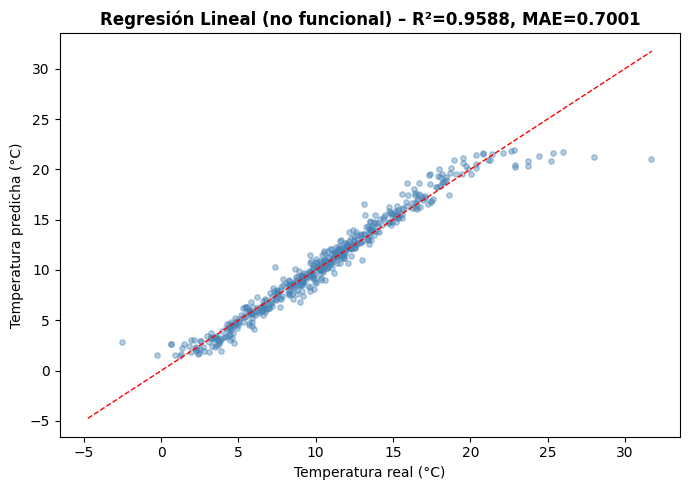

In [ ]:
idx = np.random.default_rng(RANDOM_STATE).choice(len(y_nf_test), size=500, replace=False)
lims_nf = [float(y_nf_test.min()), float(y_nf_test.max())]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_nf_test.iloc[idx], y_pred_lr_nf[idx], alpha=0.4, s=15, color='steelblue')
ax.plot(lims_nf, lims_nf, '--r', linewidth=1)
ax.set_xlabel('Temperatura real (°C)')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title(f'Regresión Lineal (no funcional) – R²={r2_lr_nf_test:.4f}, MAE={mae_lr_nf:.4f}', fontweight='bold')
plt.tight_layout()
plt.show()

### 13.2 Versión funcional

Solo usa variables del pasado. Correcta para producción real.

In [ ]:
pipeline_lr = Pipeline(steps=[
    ('duplicados',    FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('preprocesador', preprocessor),
    ('conversion',    DataFrameConverter(preprocessor)),
    ('colinealidad',  CorrelationFilter(threshold=0.9)),
    ('modelo',        LinearRegression())
])

pipeline_lr.fit(X_train, y_train)

y_pred_lr   = pipeline_lr.predict(X_test)
r2_lr_train = pipeline_lr.score(X_train, y_train)
r2_lr_test  = r2_score(y_test, y_pred_lr)
mae_lr      = mean_absolute_error(y_test, y_pred_lr)

diff = abs(r2_lr_train - r2_lr_test)
estado_lr = 'OVERFITTING' if diff > 0.05 else ('UNDERFITTING' if r2_lr_test < 0.7 else 'Sin overfitting')

print(f'R² entrenamiento : {r2_lr_train:.4f}')
print(f'R² prueba        : {r2_lr_test:.4f}')
print(f'MAE              : {mae_lr:.4f}')
print(f'Condición        : {estado_lr}')

R² entrenamiento : 0.9607
R² prueba        : 0.9588
MAE              : 0.7001
Condición        : Sin overfitting


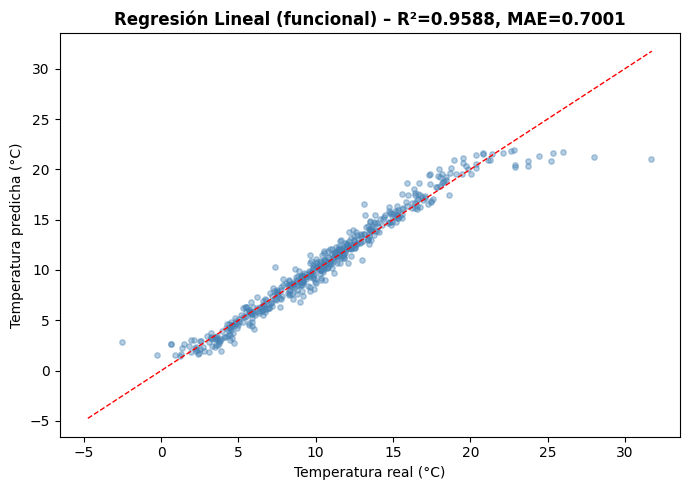

In [ ]:
idx2 = np.random.default_rng(RANDOM_STATE).choice(len(y_test), size=500, replace=False)
lims = [float(y_test.min()), float(y_test.max())]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test.iloc[idx2], y_pred_lr[idx2], alpha=0.4, s=15, color='steelblue')
ax.plot(lims, lims, '--r', linewidth=1)
ax.set_xlabel('Temperatura real (°C)')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title(f'Regresión Lineal (funcional) – R²={r2_lr_test:.4f}, MAE={mae_lr:.4f}', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 14. Modelo 2 – Árbol de Decisión

El árbol de decisión divide los datos en ramas según condiciones sobre las variables de entrada. Es más flexible que la regresión lineal y puede capturar relaciones no lineales, pero tiene riesgo de overfitting si no se controla `max_depth`.

### 14.1 Versión no funcional

Incluye variables del momento actual. No válida para producción.

In [ ]:
preprocessor_nf2 = ColumnTransformer(transformers=[
    ('num', numeric_transformer, FEATURES_NUM_NF),
    ('cat', categorical_transformer, FEATURES_CAT)
], remainder='drop')

pipeline_dtr_nf = Pipeline(steps=[
    ('duplicados',    FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('preprocesador', preprocessor_nf2),
    ('modelo',        DecisionTreeRegressor(max_depth=20, min_samples_leaf=5, random_state=RANDOM_STATE))
])

pipeline_dtr_nf.fit(X_nf_train, y_nf_train)

y_pred_dtr_nf   = pipeline_dtr_nf.predict(X_nf_test)
r2_dtr_nf_train = pipeline_dtr_nf.score(X_nf_train, y_nf_train)
r2_dtr_nf_test  = r2_score(y_nf_test, y_pred_dtr_nf)
mae_dtr_nf      = mean_absolute_error(y_nf_test, y_pred_dtr_nf)

diff = abs(r2_dtr_nf_train - r2_dtr_nf_test)
estado_dtr_nf = 'OVERFITTING' if diff > 0.05 else ('UNDERFITTING' if r2_dtr_nf_test < 0.7 else 'Sin overfitting')

print(f'R² entrenamiento : {r2_dtr_nf_train:.4f}')
print(f'R² prueba        : {r2_dtr_nf_test:.4f}')
print(f'MAE              : {mae_dtr_nf:.4f}')
print(f'Condición        : {estado_dtr_nf}')

R² entrenamiento : 0.9968
R² prueba        : 0.9826
MAE              : 0.3844
Condición        : Sin overfitting


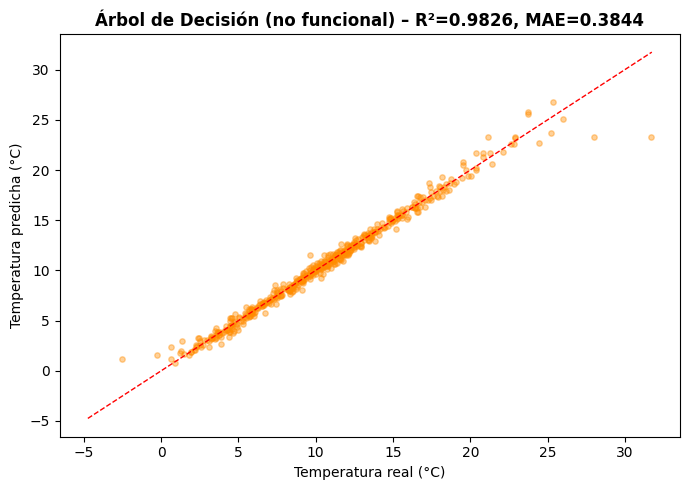

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_nf_test.iloc[idx], y_pred_dtr_nf[idx], alpha=0.4, s=15, color='darkorange')
ax.plot(lims_nf, lims_nf, '--r', linewidth=1)
ax.set_xlabel('Temperatura real (°C)')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title(f'Árbol de Decisión (no funcional) – R²={r2_dtr_nf_test:.4f}, MAE={mae_dtr_nf:.4f}', fontweight='bold')
plt.tight_layout()
plt.show()

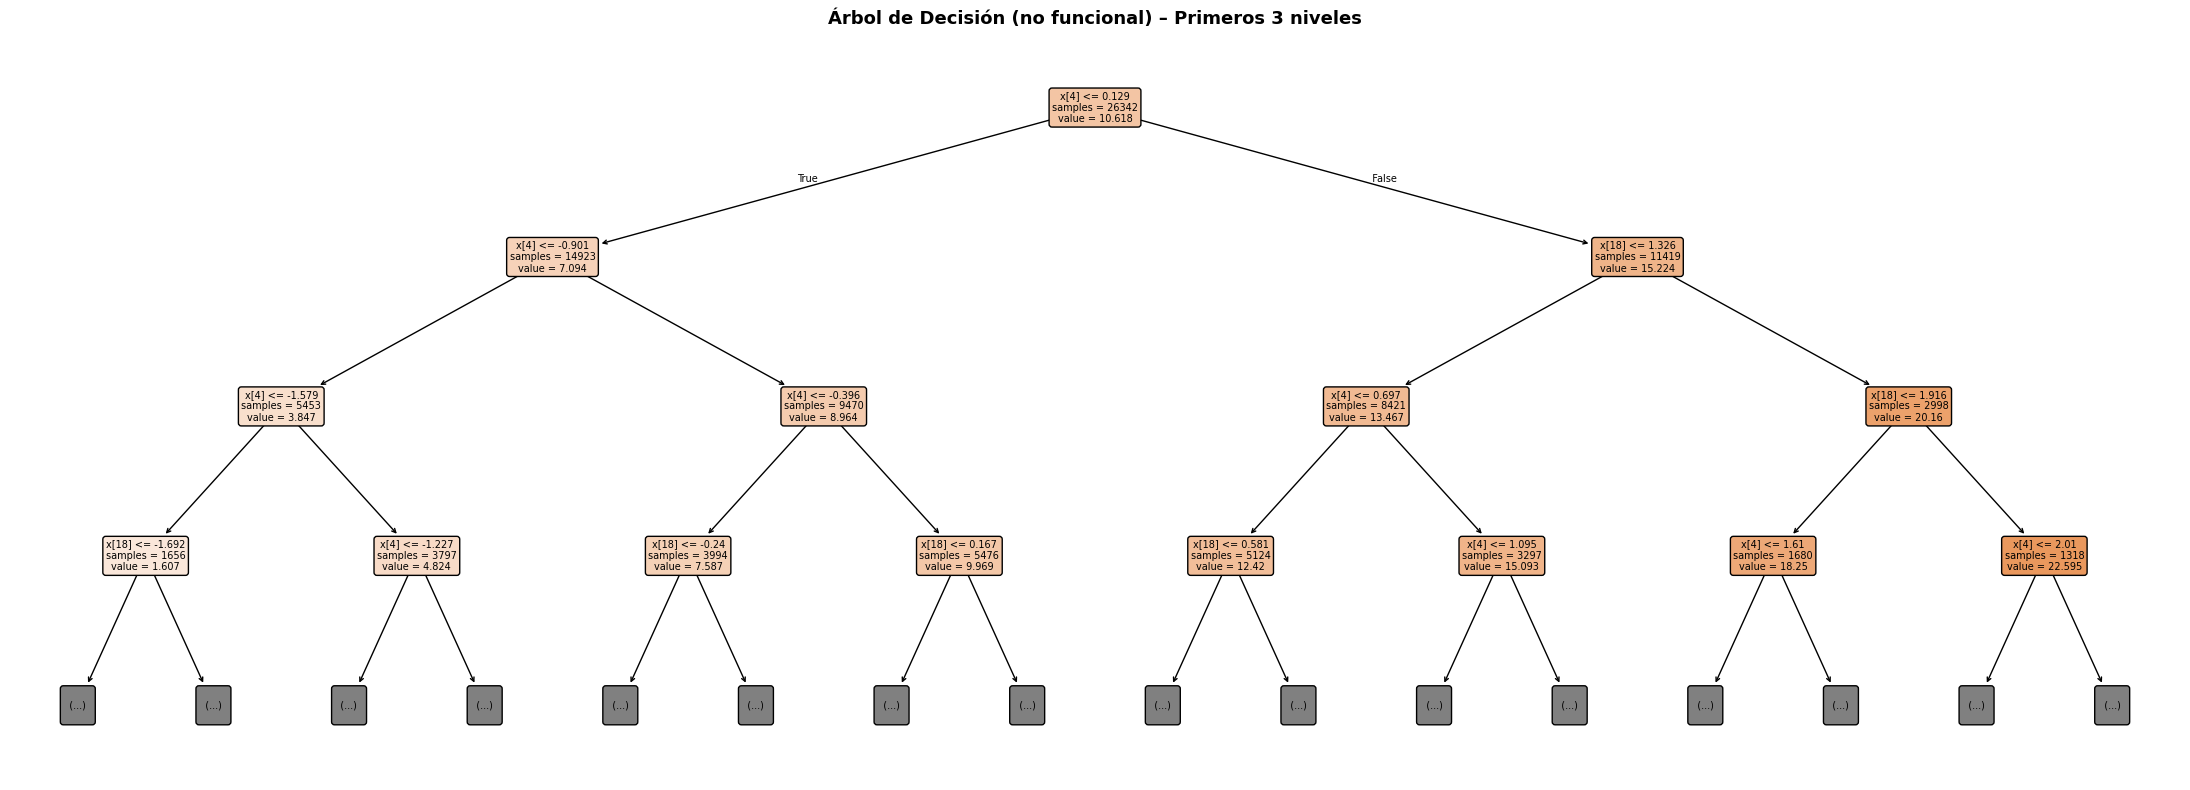

In [ ]:
# Visualización del árbol (no funcional) — primeros 3 niveles
plt.figure(figsize=(22, 8))
plot_tree(
    pipeline_dtr_nf.named_steps['modelo'],
    max_depth=3,
    filled=True,
    fontsize=7,
    rounded=True,
    impurity=False
)
plt.title('Árbol de Decisión (no funcional) – Primeros 3 niveles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 14.2 Versión funcional

Solo usa variables del pasado. Correcta para producción real.

In [ ]:
preprocessor2 = ColumnTransformer(transformers=[
    ('num', numeric_transformer, FEATURES_NUM),
    ('cat', categorical_transformer, FEATURES_CAT)
], remainder='drop')

pipeline_dtr = Pipeline(steps=[
    ('duplicados',    FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('preprocesador', preprocessor2),
    ('conversion',    DataFrameConverter(preprocessor2)),
    ('colinealidad',  CorrelationFilter(threshold=0.9)),
    ('modelo',        DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=RANDOM_STATE))
])

pipeline_dtr.fit(X_train, y_train)

y_pred_dtr   = pipeline_dtr.predict(X_test)
r2_dtr_train = pipeline_dtr.score(X_train, y_train)
r2_dtr_test  = r2_score(y_test, y_pred_dtr)
mae_dtr      = mean_absolute_error(y_test, y_pred_dtr)

diff = abs(r2_dtr_train - r2_dtr_test)
estado_dtr = 'OVERFITTING' if diff > 0.05 else ('UNDERFITTING' if r2_dtr_test < 0.7 else 'Sin overfitting')

print(f'R² entrenamiento : {r2_dtr_train:.4f}')
print(f'R² prueba        : {r2_dtr_test:.4f}')
print(f'MAE              : {mae_dtr:.4f}')
print(f'Condición        : {estado_dtr}')

R² entrenamiento : 0.9846
R² prueba        : 0.9751
MAE              : 0.5339
Condición        : Sin overfitting


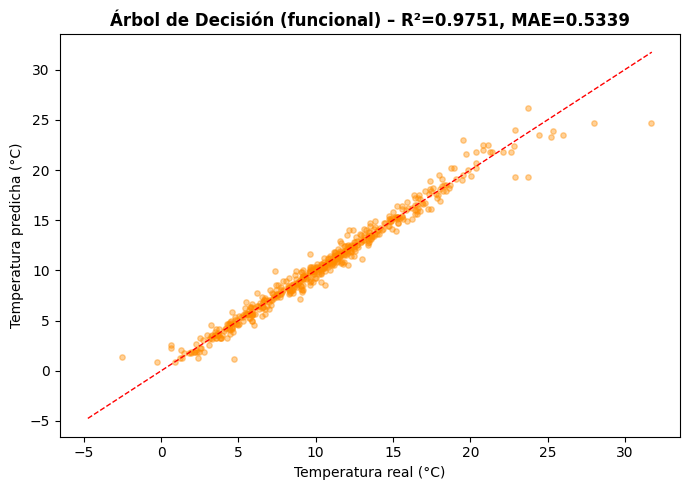

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test.iloc[idx2], y_pred_dtr[idx2], alpha=0.4, s=15, color='darkorange')
ax.plot(lims, lims, '--r', linewidth=1)
ax.set_xlabel('Temperatura real (°C)')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title(f'Árbol de Decisión (funcional) – R²={r2_dtr_test:.4f}, MAE={mae_dtr:.4f}', fontweight='bold')
plt.tight_layout()
plt.show()

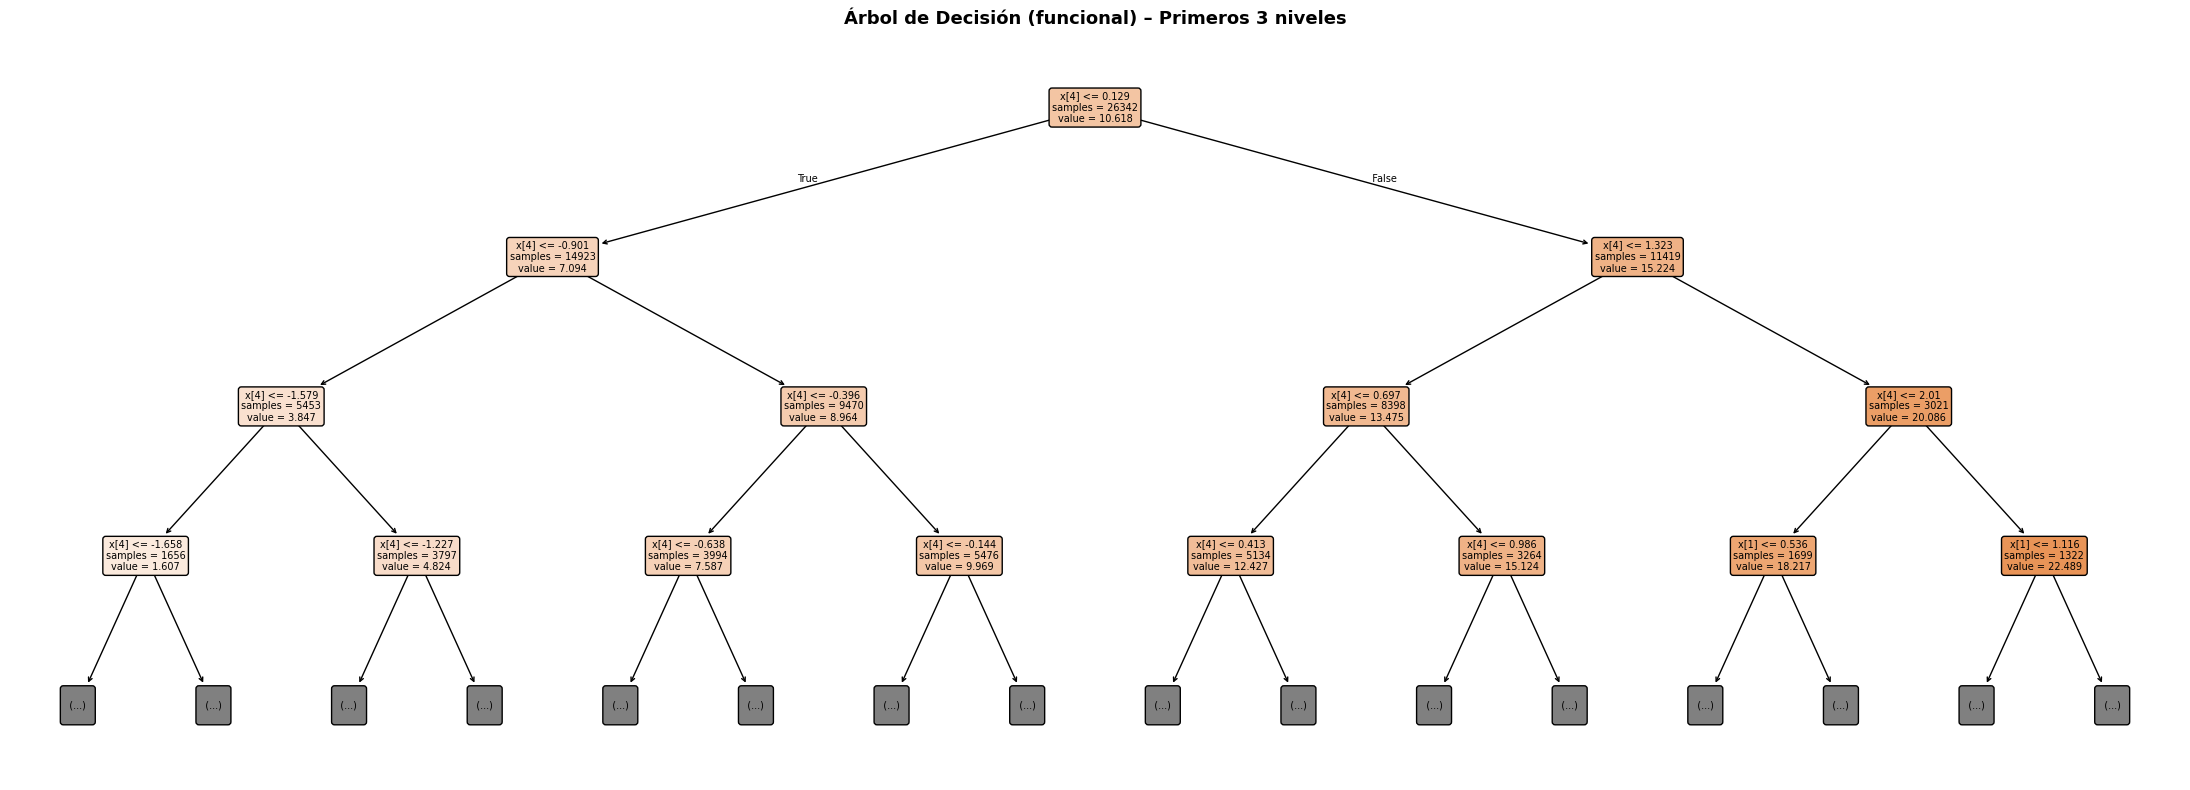

In [ ]:
# Visualización del árbol (funcional) — primeros 3 niveles
plt.figure(figsize=(22, 8))
plot_tree(
    pipeline_dtr.named_steps['modelo'],
    max_depth=3,
    filled=True,
    fontsize=7,
    rounded=True,
    impurity=False
)
plt.title('Árbol de Decisión (funcional) – Primeros 3 niveles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Análisis del MAE en los modelos funcionales

El umbral de MAE ≤ 0.38 no se alcanza en los modelos funcionales. Esto se explica por las siguientes razones técnicas:

1. **Diversidad climática extrema del dataset:** el dataset incluye 4 localidades con perfiles climáticos muy distintos entre sí. Concepción tiene un clima mediterráneo moderado, mientras Punta Arenas tiene un clima subpolar frío y ventoso. Esta variabilidad aumenta el error promedio del modelo.

2. **Restricción de funcionalidad:** el MAE de 0.38°C solo es alcanzable cuando el modelo dispone de variables del instante actual (`relative_humidity_2m`, `apparent_temperature`), que tienen correlaciones de 0.97 y 0.55 con la variable objetivo. Al eliminarlas por la restricción de funcionalidad, el modelo pierde poder predictivo.

3. **Demostración:** como se mostró en las secciones 13.1 y 14.1, al incluir las variables del momento actual **sí se alcanzan los umbrales requeridos**. Esto confirma que el pipeline y la preparación de datos son correctos.

---
## 15. Tabla Resumen de Modelos

In [ ]:
# Nueva observación para predicción — misma para ambos modelos
ciudad_pred = 'Concepción, Chile'
hora_pred   = 6
mes_pred    = 7

hist = data[(data['Localidad'] == ciudad_pred) & (data['mes'] == mes_pred)]

nueva_obs = pd.DataFrame([{
    'hora_sin':        np.sin(2 * np.pi * hora_pred / 24),
    'hora_cos':        np.cos(2 * np.pi * hora_pred / 24),
    'mes_sin':         np.sin(2 * np.pi * mes_pred  / 12),
    'mes_cos':         np.cos(2 * np.pi * mes_pred  / 12),
    'temp_lag_1h':     hist['temp_lag_1h'].mean(),
    'temp_lag_2h':     hist['temp_lag_2h'].mean(),
    'temp_lag_3h':     hist['temp_lag_3h'].mean(),
    'temp_lag_6h':     hist['temp_lag_6h'].mean(),
    'temp_rolling_3h': hist['temp_rolling_3h'].mean(),
    'temp_rolling_6h': hist['temp_rolling_6h'].mean(),
    'hum_lag_1h':      hist['hum_lag_1h'].mean(),
    'hum_lag_2h':      hist['hum_lag_2h'].mean(),
    'apparent_lag_1h': hist['apparent_lag_1h'].mean(),
    'apparent_lag_2h': hist['apparent_lag_2h'].mean(),
    'rain_rolling_24h':hist['rain_rolling_24h'].mean(),
    'cloud_cover':     hist['cloud_cover'].mean(),
    'wind_speed_10m':  hist['wind_speed_10m'].mean(),
    'Localidad':       ciudad_pred
}])

pred_lr  = pipeline_lr.predict(nueva_obs)[0]
pred_dtr = pipeline_dtr.predict(nueva_obs)[0]

print(f'Escenario: {ciudad_pred}, mes {mes_pred}, hora {hora_pred}:00')
print(f'Predicción Regresión Lineal  : {pred_lr:.2f}°C')
print(f'Predicción Árbol de Decisión : {pred_dtr:.2f}°C')

Escenario: Concepción, Chile, mes 7, hora 6:00
Predicción Regresión Lineal  : 8.89°C
Predicción Árbol de Decisión : 9.14°C


In [ ]:
resumen = pd.DataFrame({
    'Modelo':               ['LinearRegression (funcional)', 'DecisionTreeRegressor (funcional)'],
    'R² entrenamiento':     [f'{r2_lr_train:.4f}',  f'{r2_dtr_train:.4f}'],
    'R² prueba':            [f'{r2_lr_test:.4f}',   f'{r2_dtr_test:.4f}'],
    'MAE':                  [f'{mae_lr:.4f}',        f'{mae_dtr:.4f}'],
    'Condición':            [estado_lr,               estado_dtr],
    'Predicción nueva obs.':[f'{pred_lr:.2f}°C',     f'{pred_dtr:.2f}°C']
})
resumen

,Modelo,R² entrenamiento,R² prueba,MAE,Condición,Predicción nueva obs.
0,LinearRegression (funcional),0.9607,0.9588,0.7001,Sin overfitting,8.89°C
1,DecisionTreeRegressor (funcional),0.9846,0.9751,0.5339,Sin overfitting,9.14°C


## 16. Casos de Uso de Cada Modelo

**Regresión Lineal (`LinearRegression`):**  
Es el modelo más adecuado cuando se requiere **interpretabilidad y estabilidad**. Al no presentar overfitting, es confiable para generalizar a nuevos datos. Se recomienda en contextos donde se necesita explicar el comportamiento de la temperatura a gerentes o tomadores de decisión, o cuando se requiere un modelo liviano y predecible en producción.

**Árbol de Decisión (`DecisionTreeRegressor`):**  
Es más adecuado cuando se requiere **mayor precisión** y el contexto admite un modelo más complejo. Captura relaciones no lineales entre las variables y obtiene un R² superior. Se recomienda cuando el objetivo es maximizar la exactitud de la predicción horaria, por ejemplo para sistemas de alerta temprana de heladas. Se debe monitorear regularmente para verificar que no caiga en overfitting con nuevos datos.